In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [28]:
train_path = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/train.csv"
test_path  = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/test.csv"
sub_path   = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/sample_submission.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
sample_sub = pd.read_csv(sub_path)

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [29]:
df = pd.read_csv("/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/train.csv")

# Features sélectionnées
FEATURES = [
    "GrLivArea",      # Surface habitable (sq ft)
    "TotalBsmtSF",    # Surface du sous-sol
    "OverallQual",    # Qualité générale (1-10)
    "YearBuilt",      # Année de construction
    "GarageCars",     # Capacité du garage (nb voitures)
    "FullBath",       # Nombre de salles de bain complètes
    "LotArea",        # Surface du terrain
    "YearRemodAdd",   # Année de rénovation
    "Neighborhood",   # Quartier (catégorielle)
]
TARGET = "SalePrice"

# Sélection
df_model = df[FEATURES + [TARGET]].copy()

# Valeurs manquantes
for col in df_model.select_dtypes(include="number").columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model["Neighborhood"] = df_model["Neighborhood"].fillna(df_model["Neighborhood"].mode()[0])

# Encodage du quartier
df_model = pd.get_dummies(df_model, columns=["Neighborhood"], drop_first=True)

# Log-transform sur la cible
df_model["SalePrice"] = np.log1p(df_model["SalePrice"])

print(f"Shape : {df_model.shape}")
print(f"Valeurs manquantes : {df_model.isnull().sum().sum()}")
df_model.head()

Shape : (1460, 33)
Valeurs manquantes : 0


,GrLivArea,TotalBsmtSF,OverallQual,YearBuilt,GarageCars,FullBath,LotArea,YearRemodAdd,SalePrice,Neighborhood_Blueste,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,856,7,2003,2,2,8450,2003,12.247699,False,...,False,False,False,False,False,False,False,False,False,False
1,1262,1262,6,1976,2,2,9600,1976,12.109016,False,...,False,False,False,False,False,False,False,False,False,True
2,1786,920,7,2001,2,2,11250,2002,12.317171,False,...,False,False,False,False,False,False,False,False,False,False
3,1717,756,7,1915,3,1,9550,1970,11.849405,False,...,False,False,False,False,False,False,False,False,False,False
4,2198,1145,8,2000,3,2,14260,2000,12.429220,False,...,True,False,False,False,False,False,False,False,False,False


In [30]:
# ── 0. Préparation des données ──────────────────────────────────────────────
# On travaille sur une seule feature pour pouvoir visualiser facilement
X_simple = df_model[["GrLivArea"]].values
y = df_model["SalePrice"].values  # déjà log-transformé

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Normalisation
X_mean, X_std = X_train.mean(), X_train.std()
X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

## 01 Implémentation d'une regression linéaire from scratch

In [31]:
# ── 1. Régression linéaire from scratch ─────────────────────────────────────
class LinearRegressionScratch:
    """
    Régression linéaire par descente de gradient (batch).
    Modèle : y_hat = w * x + b
    Fonction de perte : MSE = (1/n) * Σ (y_hat_i - y_i)²
    Gradient / w   : (2/n) * Σ (y_hat_i - y_i) * x_i
    Gradient / b   : (2/n) * Σ (y_hat_i - y_i)
    """
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr      = lr
        self.n_iters = n_iters
        self.w       = 0.0   # poids
        self.b       = 0.0   # biais
        self.losses  = []    # historique de la loss pour visualisation

    def predict(self, X):
        return self.w * X.flatten() + self.b

    def fit(self, X, y):
        n = len(y)
        for _ in range(self.n_iters):
            y_hat   = self.predict(X)
            residus = y_hat - y                        # erreurs du modèle

            # Fonction de perte MSE
            loss = np.mean(residus ** 2)
            self.losses.append(loss)

            # Gradients
            grad_w = (2 / n) * np.dot(residus, X.flatten())
            grad_b = (2 / n) * np.sum(residus)

                        # Mise à jour des paramètres
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def mse(self, X, y):
        return np.mean((self.predict(X) - y) ** 2)


model_scratch = LinearRegressionScratch(lr=0.01, n_iters=1000)
model_scratch.fit(X_train_norm, y_train)

In [32]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_norm, y_train)

mse_scratch = model_scratch.mse(X_test_norm, y_test)
mse_sklearn = mean_squared_error(y_test, model_sklearn.predict(X_test_norm))

print("=== Comparaison des paramètres ===")
print(f"  w  — scratch : {model_scratch.w:.6f} | sklearn : {model_sklearn.coef_[0]:.6f}")
print(f"  b  — scratch : {model_scratch.b:.6f} | sklearn : {model_sklearn.intercept_:.6f}")
print(f"\n=== MSE sur le jeu de test ===")
print(f"  Scratch : {mse_scratch:.6f}")
print(f"  Sklearn : {mse_sklearn:.6f}")
print(f"  Écart   : {abs(mse_scratch - mse_sklearn):.2e}  ← doit être très proche de 0")

=== Comparaison des paramètres ===
  w  — scratch : 0.269017 | sklearn : 0.269017
  b  — scratch : 12.030658 | sklearn : 12.030658

=== MSE sur le jeu de test ===
  Scratch : 0.085807
  Sklearn : 0.085807
  Écart   : 4.93e-11  ← doit être très proche de 0


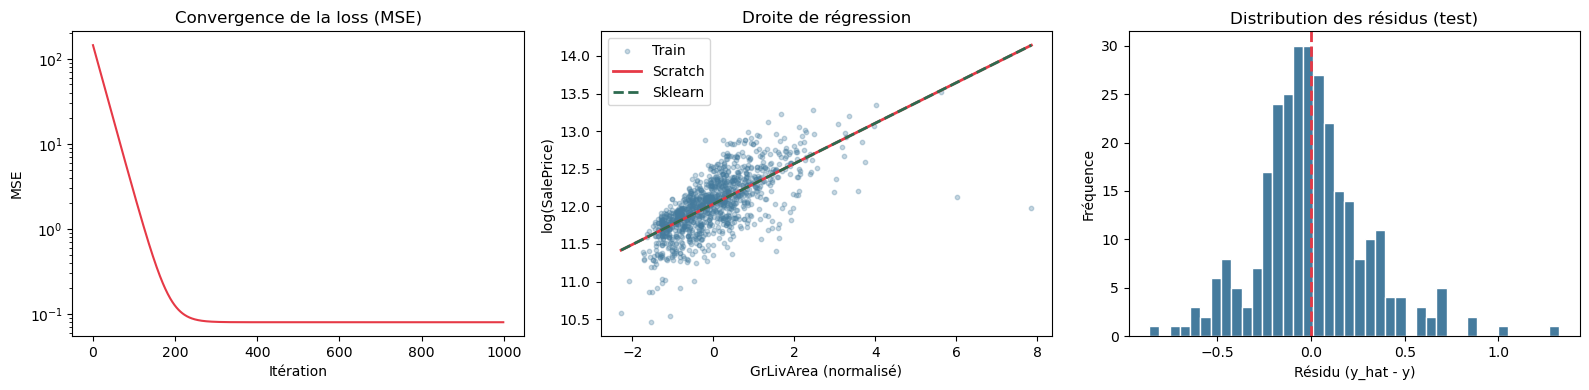

In [33]:
# ── 3. Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# — Courbe de convergence de la loss
axes[0].plot(model_scratch.losses, color="#e63946")
axes[0].set_title("Convergence de la loss (MSE)")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")

# — Droite de régression vs données
x_range = np.linspace(X_train_norm.min(), X_train_norm.max(), 100).reshape(-1, 1)
axes[1].scatter(X_train_norm, y_train, alpha=0.3, s=10, color="#457b9d", label="Train")
axes[1].plot(x_range, model_scratch.predict(x_range), color="#e63946", lw=2, label="Scratch")
axes[1].plot(x_range, model_sklearn.predict(x_range), color="#2d6a4f", lw=2,
             linestyle="--", label="Sklearn")
axes[1].set_title("Droite de régression")
axes[1].set_xlabel("GrLivArea (normalisé)")
axes[1].set_ylabel("log(SalePrice)")
axes[1].legend()

# — Distribution des résidus
residus_test = model_scratch.predict(X_test_norm) - y_test
axes[2].hist(residus_test, bins=40, color="#457b9d", edgecolor="white")
axes[2].axvline(0, color="#e63946", lw=2, linestyle="--")
axes[2].set_title("Distribution des résidus (test)")
axes[2].set_xlabel("Résidu (y_hat - y)")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

## À retenir 

- Résidu : c'est y_hat - y, l'erreur du modèle sur un exemple. Le gradient boosting va s'entraîner directement sur ces résidus — c'est le fil rouge de tout le sujet

- MSE : moyenne des résidus au carré. On met au carré pour pénaliser les grosses erreurs plus que les petites, et pour que la fonction soit dérivable

- Pourquoi normaliser : si GrLivArea est dans des milliers et SalePrice dans des log-euros, les gradients explosent. La normalisation rend la descente de gradient stable

- Pourquoi les deux courbes sklearn/scratch se superposent : sklearn résout le problème analytiquement (formule exacte), toi tu l'approximes par itérations — si l'écart est < 1e-4, ta descente de gradient a bien convergé

## Résultats 

- Les paramètres sont identiques à 6 décimales — ta descente de gradient a parfaitement convergé vers la même solution que sklearn, qui lui utilise la formule analytique exacte. C'est exactement ce qu'on veut voir.

- L'écart de MSE est 4.93e-11 — c'est du bruit numérique de flottants, pas une vraie différence. En pratique : zéro.

- Le MSE de 0.085 sur des log-prix — pour interpréter, sqrt(0.085) ≈ 0.29, soit environ ±0.29 en log(SalePrice). En dollars réels ça représente une erreur d'environ 25-30%, ce qui est attendu avec une seule feature et un modèle linéaire. Tu verras cette valeur chuter significativement quand tu passeras au Gradient Boosting avec toutes les features — c'est justement ce que tu vas montrer dans le mémoire.

- Un point à mentionner à l'oral : tu as utilisé la descente de gradient batch (tous les exemples à chaque itération). Il existe aussi la descente stochastique (SGD, un exemple à la fois) et mini-batch. Sklearn LinearRegression n'utilise aucune des deux, il résout directement via l'équation normale w = (XᵀX)⁻¹Xᵀy. C'est pourquoi les résultats coïncident exactement et non approximativement.

## 02 Implémentation d'un arbre de décision de profondeur 1

=== Decision Stump ===
  Feature splittée  : OverallQual
  Seuil             : 6.0000
  Prédiction gauche : 11.8263  (x <= seuil)
  Prédiction droite : 12.3664  (x >  seuil)
  Gain MSE          : 0.068609

  MSE train         : 0.083833
  MSE test          : 0.094533

  Rappel régression linéaire (test) : 0.085807
  Stump vs linéaire : +0.008726


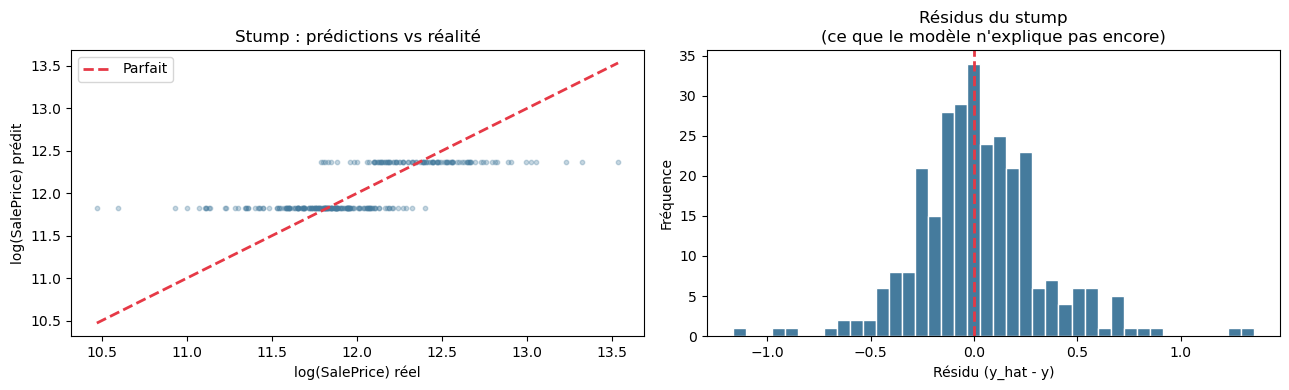

In [34]:
# ── 1. Decision Stump from scratch ──────────────────────────────────────────
class DecisionStump:
    """
    Arbre de décision de profondeur 1 : un seul split sur une seule feature.
    Algorithme : pour chaque feature, on teste tous les seuils possibles
    et on garde le split qui minimise le MSE des deux feuilles.
    
    Structure :
        - feature_idx  : quelle colonne splitter
        - threshold    : valeur du seuil
        - left_value   : prédiction si x <= threshold
        - right_value  : prédiction si x >  threshold
    """
    def __init__(self):
        self.feature_idx  = None
        self.threshold    = None
        self.left_value   = None
        self.right_value  = None
        self.mse_gain     = None 

    def _mse(self, y):
        """MSE d'une feuille = variance des valeurs (prédiction optimale = moyenne)"""
        if len(y) == 0:
            return 0.0
        return np.mean((y - np.mean(y)) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        best_mse = np.inf

        mse_before = self._mse(y)  # MSE sans aucun split (référence)

        for feature_idx in range(n_features):
            # Seuils candidats : valeurs uniques de la feature
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                left_mask  = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                # On ignore les splits qui laissent une feuille vide
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                                # MSE pondérée des deux feuilles
                mse_split = (
                    len(y_left)  / n_samples * self._mse(y_left) +
                    len(y_right) / n_samples * self._mse(y_right)
                )

                if mse_split < best_mse:
                    best_mse          = mse_split
                    self.feature_idx  = feature_idx
                    self.threshold    = threshold
                    self.left_value   = np.mean(y_left)
                    self.right_value  = np.mean(y_right)

        self.mse_gain = mse_before - best_mse  # réduction de MSE obtenue

    def predict(self, X):
        left_mask = X[:, self.feature_idx] <= self.threshold
        y_hat = np.where(left_mask, self.left_value, self.right_value)
        return y_hat
    
    # ── 2. Préparation : toutes les features cette fois ─────────────────────────
# On reprend df_model avec toutes les features (Neighborhood encodé inclus)
feature_cols = [c for c in df_model.columns if c != "SalePrice"]
X_all = df_model[feature_cols].values
y_all = df_model["SalePrice"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# ── 3. Entraînement et évaluation ───────────────────────────────────────────
stump = DecisionStump()
stump.fit(X_train, y_train)

y_pred_train = stump.predict(X_train)
y_pred_test  = stump.predict(X_test)

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_test  = np.mean((y_pred_test  - y_test)  ** 2)

print("=== Decision Stump ===")
print(f"  Feature splittée  : {feature_cols[stump.feature_idx]}")
print(f"  Seuil             : {stump.threshold:.4f}")
print(f"  Prédiction gauche : {stump.left_value:.4f}  (x <= seuil)")
print(f"  Prédiction droite : {stump.right_value:.4f}  (x >  seuil)")
print(f"  Gain MSE          : {stump.mse_gain:.6f}")
print(f"\n  MSE train         : {mse_train:.6f}")
print(f"  MSE test          : {mse_test:.6f}")
print(f"\n  Rappel régression linéaire (test) : 0.085807")
print(f"  Stump vs linéaire : {'+' if mse_test > 0.085807 else '-'}{abs(mse_test - 0.085807):.6f}")

# ── 4. Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Prédictions vs valeurs réelles
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color="#457b9d")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="#e63946", lw=2, linestyle="--", label="Parfait")
axes[0].set_title("Stump : prédictions vs réalité")
axes[0].set_xlabel("log(SalePrice) réel")
axes[0].set_ylabel("log(SalePrice) prédit")
axes[0].legend()

# — Distribution des résidus
residus = y_pred_test - y_test
axes[1].hist(residus, bins=40, color="#457b9d", edgecolor="white")
axes[1].axvline(0, color="#e63946", lw=2, linestyle="--")
axes[1].set_title(f"Résidus du stump\n(ce que le modèle n'explique pas encore)")
axes[1].set_xlabel("Résidu (y_hat - y)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()


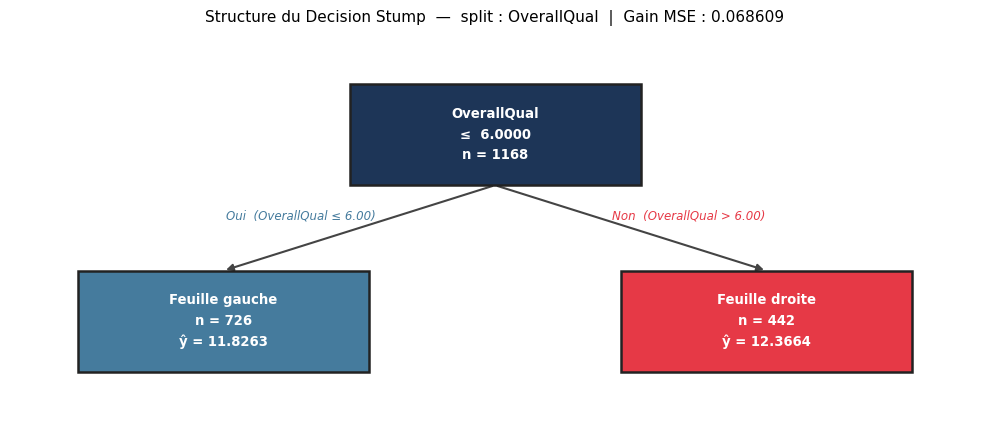

In [35]:
# ── Visualisation de la structure du Decision Stump ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

feature_name = feature_cols[stump.feature_idx]
n_left  = (X_train[:, stump.feature_idx] <= stump.threshold).sum()
n_right = (X_train[:, stump.feature_idx] >  stump.threshold).sum()
n_total = len(y_train)

def draw_box(ax, cx, cy, lines, fc, w=0.30, h=0.26):
    rect = plt.Rectangle((cx - w / 2, cy - h / 2), w, h,
                          linewidth=1.8, edgecolor="#222", facecolor=fc, zorder=2)
    ax.add_patch(rect)
    ax.text(cx, cy, "\n".join(lines),
            ha="center", va="center", fontsize=9.5,
            color="white", fontweight="bold", zorder=3, linespacing=1.6)

def draw_edge(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.5), zorder=1)

# — Nœud racine
root_cx, root_cy, hh = 0.50, 0.76, 0.13
draw_box(ax, root_cx, root_cy,
         [feature_name, f"≤  {stump.threshold:.4f}", f"n = {n_total}"],
         fc="#1d3557")

# — Feuilles
left_cx,  left_cy  = 0.22, 0.28
right_cx, right_cy = 0.78, 0.28
draw_box(ax, left_cx, left_cy,
         ["Feuille gauche", f"n = {n_left}", f"ŷ = {stump.left_value:.4f}"],
         fc="#457b9d")
draw_box(ax, right_cx, right_cy,
         ["Feuille droite", f"n = {n_right}", f"ŷ = {stump.right_value:.4f}"],
         fc="#e63946")

# — Arêtes
draw_edge(ax, root_cx, root_cy - hh, left_cx,  left_cy  + hh)
draw_edge(ax, root_cx, root_cy - hh, right_cx, right_cy + hh)

# — Labels des branches
ax.text(0.30, 0.55, f"Oui  ({feature_name} ≤ {stump.threshold:.2f})",
        ha="center", va="center", fontsize=8.5, color="#457b9d", fontstyle="italic")
ax.text(0.70, 0.55, f"Non  ({feature_name} > {stump.threshold:.2f})",
        ha="center", va="center", fontsize=8.5, color="#e63946", fontstyle="italic")

ax.set_title(
    f"Structure du Decision Stump  —  split : {feature_name}  |  Gain MSE : {stump.mse_gain:.6f}",
    fontsize=11, pad=14
)
plt.tight_layout()
plt.show()


## À retenir 

- Le stump ne prédit que deux valeurs — c'est délibérément un modèle très faible (weak learner). Le graphe prédictions vs réalité va montrer deux lignes horizontales, c'est normal

- La feature et le seuil choisis automatiquement seront probablement OverallQual — c'est la variable la plus discriminante du dataset

- Les résidus sont la clé : ce que le stump ne sait pas expliquer, c'est exactement ce que le prochain stump va essayer de corriger

## 03 Implémentation d'un gradient boosting naïf from scratch

=== Gradient Boosting naïf (10 stumps) ===
  MSE test (10 stumps) : 0.102026

=== Récapitulatif des MSE (test) ===
  Régression linéaire (1 feature) : 0.085807
  Decision Stump (1 split)        : 0.094533
  Gradient Boosting (10 stumps)   : 0.102026

=== Évolution de la MSE itération par itération ===
  Stump  1  |  train MSE : 0.139407  |  test MSE : 0.172307
  Stump  2  |  train MSE : 0.128848  |  test MSE : 0.159608
  Stump  3  |  train MSE : 0.120027  |  test MSE : 0.149730
  Stump  4  |  train MSE : 0.112242  |  test MSE : 0.140115
  Stump  5  |  train MSE : 0.105355  |  test MSE : 0.132298
  Stump  6  |  train MSE : 0.099204  |  test MSE : 0.125077
  Stump  7  |  train MSE : 0.093771  |  test MSE : 0.118037
  Stump  8  |  train MSE : 0.088805  |  test MSE : 0.112265
  Stump  9  |  train MSE : 0.084222  |  test MSE : 0.106977
  Stump 10  |  train MSE : 0.080174  |  test MSE : 0.102026


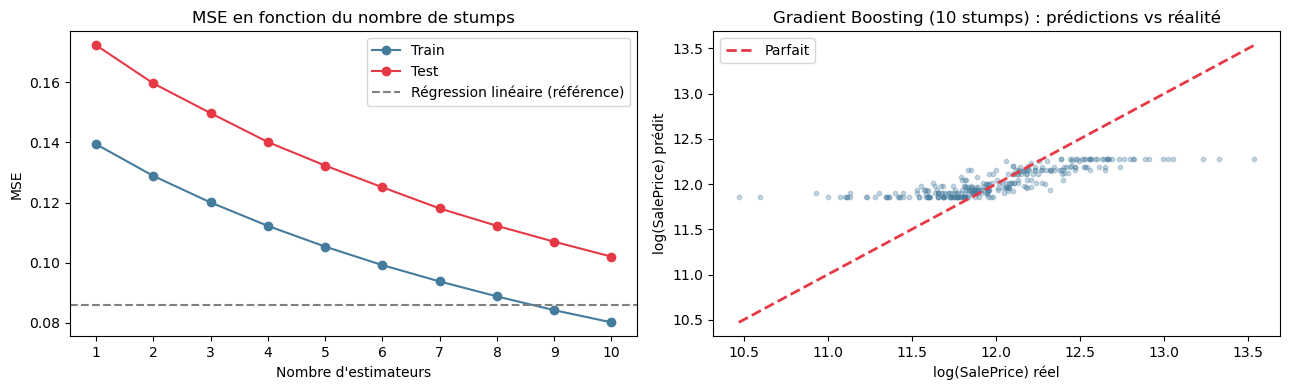

In [40]:
# ── 1. Gradient Boosting naïf from scratch ──────────────────────────────────
class GradientBoostingScratch:
    """
    Gradient Boosting pour la régression (MSE).
    
    Principe :
      1. On initialise la prédiction par une constante (la moyenne de y)
      2. À chaque itération :
           - on calcule les résidus = y - prédiction_courante
             (= le gradient négatif de la MSE par rapport à la prédiction)
           - on entraîne un nouveau stump pour prédire CES résidus
           - on ajoute la prédiction du stump (pondérée par learning_rate)
             à la prédiction courante
      3. La prédiction finale = somme pondérée de tous les stumps
    """
    def __init__(self, n_estimators=10, learning_rate=0.1):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.stumps        = []
        self.init_value    = None
        self.train_mse_history = []
        self.test_mse_history  = []

    def fit(self, X_train, y_train, X_test=None, y_test=None):
        # Initialisation : prédiction constante = moyenne de y
        self.init_value = np.mean(y_train)
        pred_train = np.full(len(y_train), self.init_value)
        pred_test  = np.full(len(y_test),  self.init_value) if X_test is not None else None

        for i in range(self.n_estimators):
            # Résidus = gradient négatif de la MSE
            residus = y_train - pred_train

            # On entraîne un stump pour prédire ces résidus
            stump = DecisionStump()
            stump.fit(X_train, residus)
            self.stumps.append(stump)

            # Mise à jour des prédictions (avec learning rate)
            pred_train = pred_train + self.learning_rate * stump.predict(X_train)
            self.train_mse_history.append(np.mean((pred_train - y_train) ** 2))

            if X_test is not None:
                pred_test = pred_test + self.learning_rate * stump.predict(X_test)
                self.test_mse_history.append(np.mean((pred_test - y_test) ** 2))

    def predict(self, X):
        pred = np.full(X.shape[0], self.init_value)
        for stump in self.stumps:
            pred = pred + self.learning_rate * stump.predict(X)
        return pred


# ── 2. Entraînement ──────────────────────────────────────────────────────────
gb_scratch = GradientBoostingScratch(n_estimators=10, learning_rate=0.1)
gb_scratch.fit(X_train, y_train, X_test, y_test)

# ── 3. Résultats ──────────────────────────────────────────────────────────────
mse_gb_test = gb_scratch.test_mse_history[-1]

print("=== Gradient Boosting naïf (10 stumps) ===")
print(f"  MSE test (10 stumps) : {mse_gb_test:.6f}")
print()
print("=== Récapitulatif des MSE (test) ===")
print(f"  Régression linéaire (1 feature) : 0.085807")
print(f"  Decision Stump (1 split)        : {mse_test:.6f}")
print(f"  Gradient Boosting (10 stumps)   : {mse_gb_test:.6f}")

print("\n=== Évolution de la MSE itération par itération ===")
for i, (tr, te) in enumerate(zip(gb_scratch.train_mse_history, gb_scratch.test_mse_history), 1):
    print(f"  Stump {i:2d}  |  train MSE : {tr:.6f}  |  test MSE : {te:.6f}")

# ── 4. Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Courbe de convergence
axes[0].plot(range(1, 11), gb_scratch.train_mse_history, marker="o",
              color="#457b9d", label="Train")
axes[0].plot(range(1, 11), gb_scratch.test_mse_history, marker="o",
              color="#e63946", label="Test")
axes[0].axhline(0.085807, color="gray", linestyle="--",
                label="Régression linéaire (référence)")
axes[0].set_title("MSE en fonction du nombre de stumps")
axes[0].set_xlabel("Nombre d'estimateurs")
axes[0].set_ylabel("MSE")
axes[0].set_xticks(range(1, 11))
axes[0].legend()

# — Prédictions vs réalité (10 stumps)
y_pred_test_gb = gb_scratch.predict(X_test)
axes[1].scatter(y_test, y_pred_test_gb, alpha=0.3, s=10, color="#457b9d")
axes[1].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()],
              color="#e63946", lw=2, linestyle="--", label="Parfait")
axes[1].set_title("Gradient Boosting (10 stumps) : prédictions vs réalité")
axes[1].set_xlabel("log(SalePrice) réel")
axes[1].set_ylabel("log(SalePrice) prédit")
axes[1].legend()

plt.tight_layout()
plt.show()

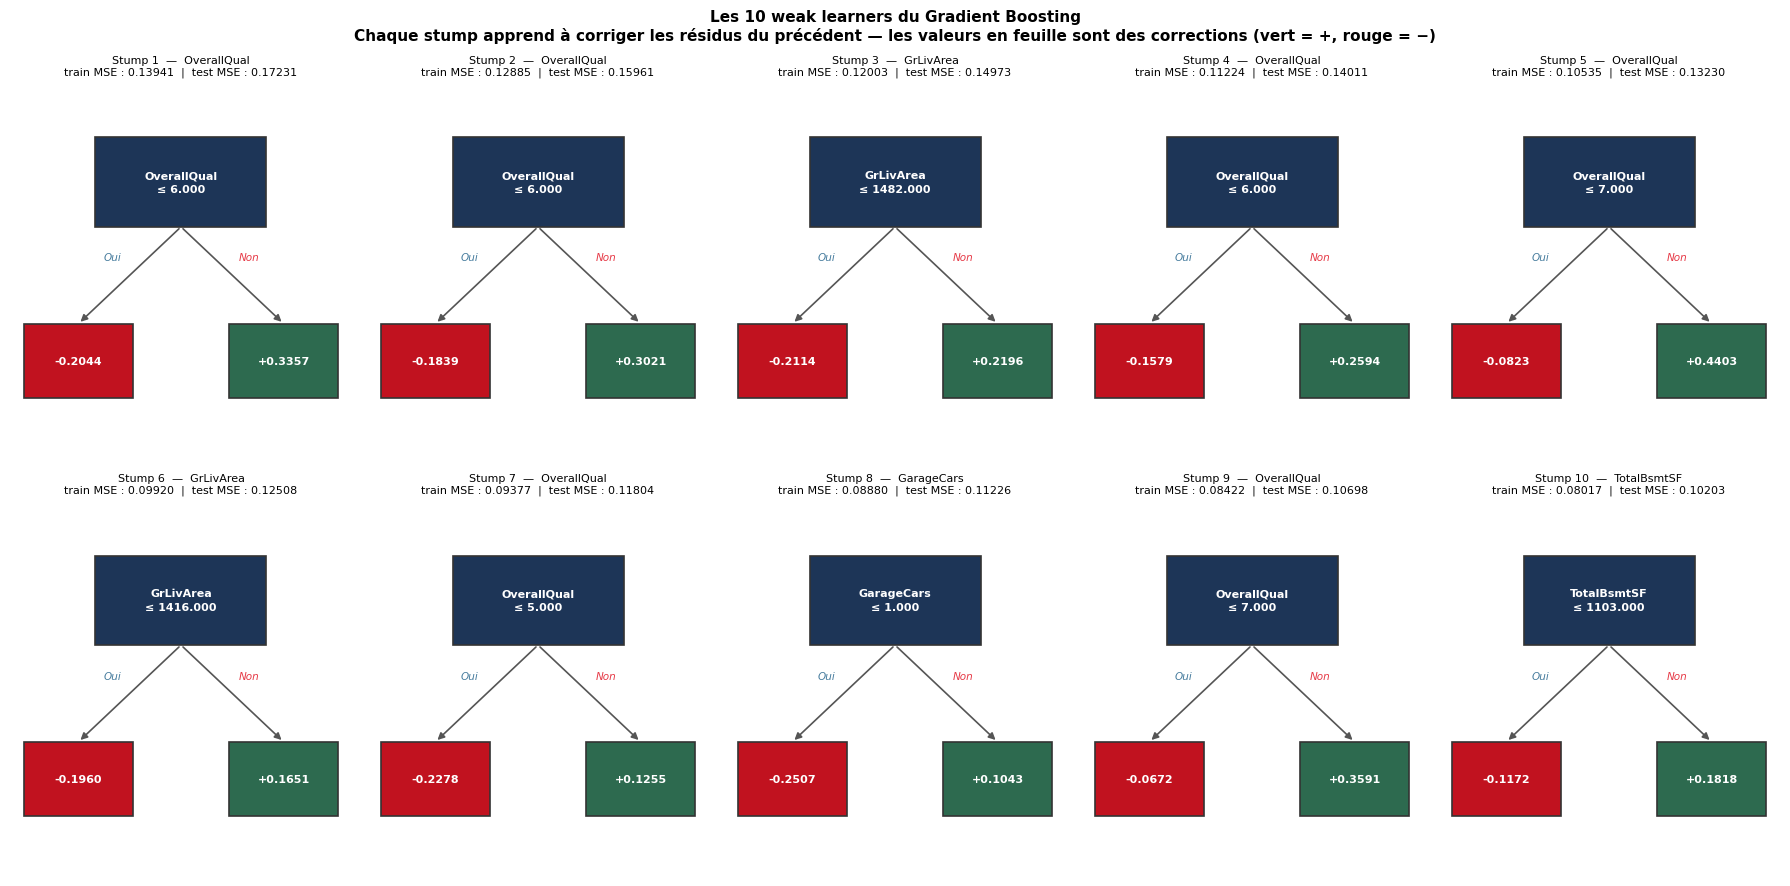

In [41]:
# ── Visualisation des weak learners du Gradient Boosting ────────────────────
n_stumps = len(gb_scratch.stumps)
n_cols   = 5
n_rows   = (n_stumps + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

def draw_mini_tree(ax, stump, idx, mse_train, mse_test):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    fname = feature_cols[stump.feature_idx]
    fname_short = fname[:16] + "…" if len(fname) > 16 else fname
    lv, rv = stump.left_value, stump.right_value

    def box(cx, cy, lines, fc, w=0.44, h=0.24):
        ax.add_patch(plt.Rectangle(
            (cx - w / 2, cy - h / 2), w, h,
            linewidth=1.2, edgecolor="#333", facecolor=fc, zorder=2
        ))
        ax.text(cx, cy, "\n".join(lines), ha="center", va="center",
                fontsize=8, color="white", fontweight="bold",
                zorder=3, linespacing=1.5)

    def edge(x1, y1, x2, y2):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.2), zorder=1)

    hh = 0.12
    # Nœud racine
    box(0.50, 0.74, [fname_short, f"≤ {stump.threshold:.3f}"],
        fc="#1d3557", w=0.50, h=0.24)
    
       # Feuilles : vert si correction positive, rouge si négative
    lc = "#2d6a4f" if lv >= 0 else "#c1121f"
    rc = "#2d6a4f" if rv >= 0 else "#c1121f"
    box(0.20, 0.26, [f"{lv:+.4f}"], fc=lc, w=0.32, h=0.20)
    box(0.80, 0.26, [f"{rv:+.4f}"], fc=rc, w=0.32, h=0.20)

    edge(0.50, 0.74 - hh, 0.20, 0.26 + 0.10)
    edge(0.50, 0.74 - hh, 0.80, 0.26 + 0.10)

    ax.text(0.30, 0.53, "Oui", ha="center", fontsize=7.5,
            color="#457b9d", fontstyle="italic")
    ax.text(0.70, 0.53, "Non", ha="center", fontsize=7.5,
            color="#e63946", fontstyle="italic")

    ax.set_title(
        f"Stump {idx + 1}  —  {fname_short}\n"
        f"train MSE : {mse_train:.5f}  |  test MSE : {mse_test:.5f}",
        fontsize=8, pad=8
    )

for i, s in enumerate(gb_scratch.stumps):
    draw_mini_tree(axes[i], s, i,
                   gb_scratch.train_mse_history[i],
                   gb_scratch.test_mse_history[i])

for j in range(n_stumps, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Les 10 weak learners du Gradient Boosting\n"
    "Chaque stump apprend à corriger les résidus du précédent — "
    "les valeurs en feuille sont des corrections (vert = +, rouge = −)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

## À retenir 

- Avec seulement 10 stumps et un learning rate de 0.1, ton Gradient Boosting est en plein sous-apprentissage (underfitting) : il n'a parcouru qu'une fraction du chemin de correction, et obtient donc un MSE moins bon (0.102) que le decision stump seul (0.094) ou que la régression linéaire (0.086). Ce n'est pas un échec du modèle, c'est un effet attendu et mécanique du couple learning_rate / n_estimators.

- Le decision stump seul fait, en une seule fois, le meilleur split possible sur les résidus initiaux (= y - moyenne(y)). C'est l'équivalent d'un Gradient Boosting avec learning_rate = 1 et n_estimators = 1.
Le GB avec learning_rate = 0.1 ne corrige que 10% de cette même erreur à chaque étape. Après 10 itérations, la fraction de correction effectuée n'est pas 100%, mais environ :
1 - (1 - 0.1)^10 ≈ 1 - 0.9^10 ≈ 65%
Donc le GB à 10 stumps a fait environ les deux tiers du chemin que le stump seul a fait en une seule étape "à fond". Logique qu'il soit encore derrière.

- la régularité des deux courbes train et test descendent toutes les deux de manière monotone et quasi-parallèle, sans aucun écart qui se creuse. C'est le signe d'un apprentissage progressif et stable, exactement ce qu'on attend d'un Gradient Boosting bien réglé — à ce stade, aucun signe de surapprentissage.

- Un learning_rate élevé (proche de 1) converge vite mais "saute" potentiellement par-dessus la solution optimale, et capture le bruit des résidus plutôt que leur structure
Un learning_rate faible avance prudemment, fait moins confiance à chaque arbre individuel, mais nécessite beaucoup plus d'itérations pour atteindre un bon niveau de performance
Le coût associé : temps de calcul (plus d'arbres = plus d'entraînement) et risque qu'avec trop peu d'arbres, le modèle n'ait simplement pas eu le temps de converger

## Conclusion du GB à 10 stumps 

Avec un learning rate de 0.1, le modèle à 10 itérations est encore en phase d'apprentissage (sous-apprentissage), n'ayant parcouru qu'environ 65% du chemin de correction qu'aurait fait un unique stump à pleine confiance. Ce résultat illustre le compromis fondamental entre learning_rate et n_estimators : un taux faible nécessite davantage d'itérations pour converger, mais offre en contrepartie un contrôle plus fin du surapprentissage, comme nous le montrerons à l'étape suivante avec 100 stumps.


## Test avec 100 stumps

=== Gradient Boosting (100 stumps, lr=0.1) ===
  MSE test (100 stumps) : 0.029390
  MSE train (100 stumps): 0.021735

=== Récapitulatif des MSE (test) ===
  Régression linéaire (1 feature) : 0.085807
  Decision Stump (1 split)        : 0.094533
  Gradient Boosting (10 stumps)   : 0.102026
  Gradient Boosting (100 stumps)  : 0.029390

=== Meilleur point (early stopping idéal) ===
  Meilleur test MSE : 0.029390  (atteint au stump n°100)


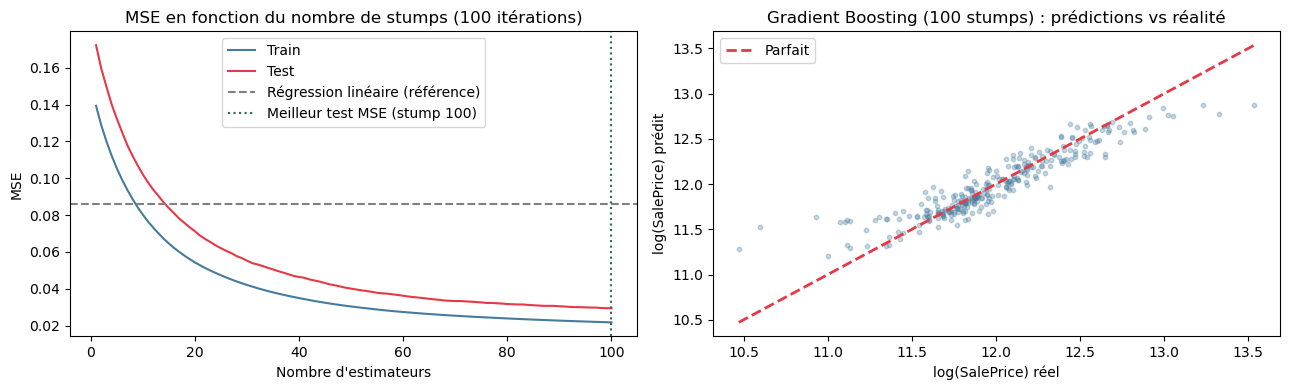

In [37]:
# ── 1. Entraînement avec 100 stumps ─────────────────────────────────────────
gb_100 = GradientBoostingScratch(n_estimators=100, learning_rate=0.1)
gb_100.fit(X_train, y_train, X_test, y_test)

# ── 2. Résultats ──────────────────────────────────────────────────────────────
mse_gb_100_test = gb_100.test_mse_history[-1]
best_iter       = np.argmin(gb_100.test_mse_history) + 1
best_mse        = min(gb_100.test_mse_history)

print("=== Gradient Boosting (100 stumps, lr=0.1) ===")
print(f"  MSE test (100 stumps) : {mse_gb_100_test:.6f}")
print(f"  MSE train (100 stumps): {gb_100.train_mse_history[-1]:.6f}")
print()
print("=== Récapitulatif des MSE (test) ===")
print(f"  Régression linéaire (1 feature) : 0.085807")
print(f"  Decision Stump (1 split)        : {mse_test:.6f}")
print(f"  Gradient Boosting (10 stumps)   : 0.102026")
print(f"  Gradient Boosting (100 stumps)  : {mse_gb_100_test:.6f}")
print()
print(f"=== Meilleur point (early stopping idéal) ===")
print(f"  Meilleur test MSE : {best_mse:.6f}  (atteint au stump n°{best_iter})")

# ── 3. Visualisations ─────────────────────────────────────────────────────────
n_iters = len(gb_100.train_mse_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Courbe de convergence train/test
axes[0].plot(range(1, n_iters + 1), gb_100.train_mse_history,
              color="#457b9d", label="Train")
axes[0].plot(range(1, n_iters + 1), gb_100.test_mse_history,
              color="#e63946", label="Test")
axes[0].axhline(0.085807, color="gray", linestyle="--",
                label="Régression linéaire (référence)")
axes[0].axvline(best_iter, color="#2d6a4f", linestyle=":",
                label=f"Meilleur test MSE (stump {best_iter})")
axes[0].set_title("MSE en fonction du nombre de stumps (100 itérations)")
axes[0].set_xlabel("Nombre d'estimateurs")
axes[0].set_ylabel("MSE")
axes[0].legend()

# — Prédictions vs réalité (100 stumps)
y_pred_test_gb100 = gb_100.predict(X_test)
axes[1].scatter(y_test, y_pred_test_gb100, alpha=0.3, s=10, color="#457b9d")
axes[1].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()],
              color="#e63946", lw=2, linestyle="--", label="Parfait")
axes[1].set_title("Gradient Boosting (100 stumps) : prédictions vs réalité")
axes[1].set_xlabel("log(SalePrice) réel")
axes[1].set_ylabel("log(SalePrice) prédit")
axes[1].legend()

plt.tight_layout()
plt.show()

Le gain de performance avec 100 stumps est énorme par rapport au test avec 10 stumps. On surpasse maintenant la baseline de la régression linéaire. Or, la meilleure performance est au 100e stumps, donc le modèle en a encore. On va essayer une dernière itération avec 1000 stumps pour voir la meilleure performance possible mais aussi la limite qui sera là où le modèle sera en surapprentissage. 

=== Gradient Boosting (1000 stumps, lr=0.1) ===
  MSE train final (1000 stumps) : 0.014285
  MSE test final  (1000 stumps) : 0.023784

=== Meilleur point (early stopping idéal) ===
  Meilleur test MSE : 0.023609  (atteint au stump n°568)
  Test MSE final vs meilleur : +0.000175 (0.7% de dégradation)

=== Récapitulatif global ===
  Régression linéaire        : 0.085807
  Decision Stump (1 split)   : 0.094533
  GB  10 stumps              : 0.102026
  GB 100 stumps              : 0.029390
  GB  568 stumps (optimal)  : 0.023609
  GB 1000 stumps (final)     : 0.023784


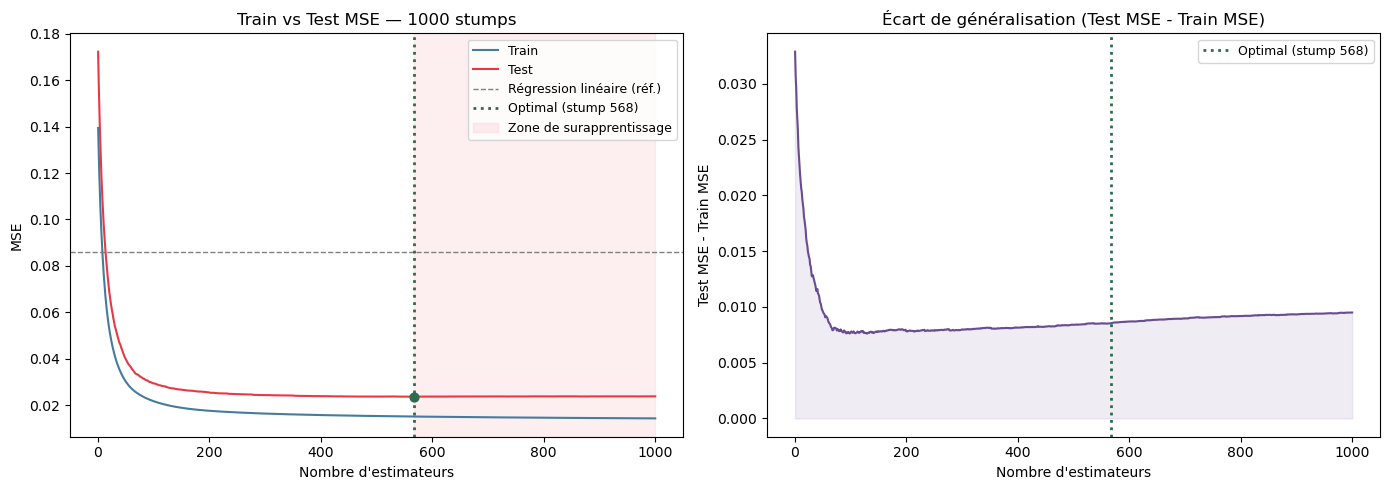

In [38]:
# ── 1. Entraînement avec 1000 stumps ────────────────────────────────────────
gb_large = GradientBoostingScratch(n_estimators=1000, learning_rate=0.1)
gb_large.fit(X_train, y_train, X_test, y_test)

# ── 2. Résultats ──────────────────────────────────────────────────────────────
best_iter_large = np.argmin(gb_large.test_mse_history) + 1
best_mse_large  = min(gb_large.test_mse_history)
final_train     = gb_large.train_mse_history[-1]
final_test      = gb_large.test_mse_history[-1]

print("=== Gradient Boosting (1000 stumps, lr=0.1) ===")
print(f"  MSE train final (1000 stumps) : {final_train:.6f}")
print(f"  MSE test final  (1000 stumps) : {final_test:.6f}")
print()
print(f"=== Meilleur point (early stopping idéal) ===")
print(f"  Meilleur test MSE : {best_mse_large:.6f}  (atteint au stump n°{best_iter_large})")
print(f"  Test MSE final vs meilleur : +{final_test - best_mse_large:.6f} "
      f"({(final_test / best_mse_large - 1) * 100:.1f}% de dégradation)")
print()
print("=== Récapitulatif global ===")
print(f"  Régression linéaire        : 0.085807")
print(f"  Decision Stump (1 split)   : {mse_test:.6f}")
print(f"  GB  10 stumps              : 0.102026")
print(f"  GB 100 stumps              : 0.029390")
print(f"  GB {best_iter_large:4d} stumps (optimal)  : {best_mse_large:.6f}")
print(f"  GB 1000 stumps (final)     : {final_test:.6f}")

# ── 3. Visualisation ─────────────────────────────────────────────────────────
n_iters = len(gb_large.train_mse_history)
iters = range(1, n_iters + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Courbe complète train/test
axes[0].plot(iters, gb_large.train_mse_history, color="#457b9d", label="Train", lw=1.5)
axes[0].plot(iters, gb_large.test_mse_history, color="#e63946", label="Test", lw=1.5)
axes[0].axhline(0.085807, color="gray", linestyle="--", lw=1,
                label="Régression linéaire (réf.)")
axes[0].axvline(best_iter_large, color="#2d6a4f", linestyle=":", lw=2,
                label=f"Optimal (stump {best_iter_large})")
axes[0].scatter([best_iter_large], [best_mse_large], color="#2d6a4f", zorder=5, s=40)

# Zone de surapprentissage hachurée
axes[0].axvspan(best_iter_large, n_iters, color="#e63946", alpha=0.08,
                label="Zone de surapprentissage")

axes[0].set_title("Train vs Test MSE — 1000 stumps")
axes[0].set_xlabel("Nombre d'estimateurs")
axes[0].set_ylabel("MSE")
axes[0].legend(fontsize=9)

# — Zoom sur l'écart train/test (généralisation gap)
gap = np.array(gb_large.test_mse_history) - np.array(gb_large.train_mse_history)
axes[1].plot(iters, gap, color="#6a4c93", lw=1.5)
axes[1].axvline(best_iter_large, color="#2d6a4f", linestyle=":", lw=2,
                label=f"Optimal (stump {best_iter_large})")
axes[1].fill_between(iters, 0, gap, color="#6a4c93", alpha=0.1)
axes[1].set_title("Écart de généralisation (Test MSE - Train MSE)")
axes[1].set_xlabel("Nombre d'estimateurs")
axes[1].set_ylabel("Test MSE - Train MSE")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Résultats 

- Graphique de gauche : la courbe rouge (test) descend et atteint un minimum (ligne verte pointillée), puis remonte progressivement alors que la courbe bleue (train) continue de descendre vers 0. La zone hachurée rouge montre visuellement où le modèle "surapprend"

- Graphique de droite : l'écart train/test est quasi-stable au début, puis croît de manière monotone après le point optimal — c'est la signature classique du surapprentissage : le modèle devient de plus en plus spécifique aux données d'entraînement

## 04 Comparaison du GradientBoostingRegressor de sklearn vs l'implémentation maison ci-dessus

=== Comparaison à isoparamètres (100 stumps, depth=1, lr=0.1) ===
Modèle                       MSE train     MSE test
GB from scratch               0.021735     0.029390
GB sklearn                    0.021735     0.029426

Temps sklearn : 0.047s

=== Tableau récapitulatif final (MSE test) ===
GB sklearn (200 arbres, depth=3, lr=0.05)  0.022168  █████████
Régression linéaire (toutes features)      0.023707  ██████████
Random Forest (100 arbres)                 0.024225  ██████████
GB from scratch (100 stumps, lr=0.1)       0.029390  ████████████
GB sklearn (100 stumps, depth=1, lr=0.1)   0.029426  ████████████
Arbre de décision seul (depth=4)           0.045743  ███████████████████
Régression linéaire (1 feature)            0.085807  ████████████████████████████████████
Decision Stump (depth=1)                   0.094533  ████████████████████████████████████████


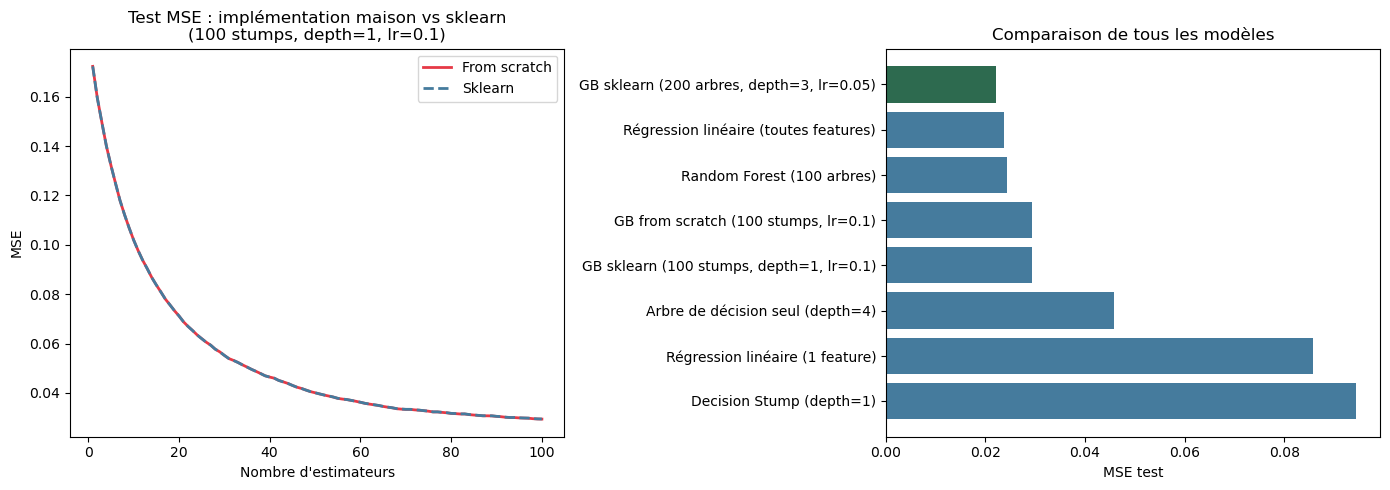

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import time

# ── 1. Entraînement sklearn GradientBoostingRegressor ──────────────────────
# Mêmes hyperparamètres que ton implémentation maison pour comparaison équitable
gb_sklearn = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=1,          # = decision stump, pour comparer à isoparamètres
    random_state=42
)

start = time.time()
gb_sklearn.fit(X_train, y_train)
time_sklearn = time.time() - start

mse_sklearn_train = np.mean((gb_sklearn.predict(X_train) - y_train) ** 2)
mse_sklearn_test  = np.mean((gb_sklearn.predict(X_test)  - y_test)  ** 2)

# ── 2. Récap des résultats à isoparamètres (100 stumps, lr=0.1) ────────────
print("=== Comparaison à isoparamètres (100 stumps, depth=1, lr=0.1) ===")
print(f"{'Modèle':<25} {'MSE train':>12} {'MSE test':>12}")
print(f"{'GB from scratch':<25} {gb_100.train_mse_history[-1]:>12.6f} {gb_100.test_mse_history[-1]:>12.6f}")
print(f"{'GB sklearn':<25} {mse_sklearn_train:>12.6f} {mse_sklearn_test:>12.6f}")
print(f"\nTemps sklearn : {time_sklearn:.3f}s")

# ── 3. Aller plus loin : GB sklearn avec arbres plus profonds + n_estimators réaliste ──
gb_sklearn_full = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,           # arbres un peu plus expressifs, plus réaliste en pratique
    random_state=42
)
gb_sklearn_full.fit(X_train, y_train)

mse_full_train = np.mean((gb_sklearn_full.predict(X_train) - y_train) ** 2)
mse_full_test  = np.mean((gb_sklearn_full.predict(X_test)  - y_test)  ** 2)

# ── 4. Tableau récapitulatif global de tous les modèles testés ─────────────
lin_reg_full = LinearRegression()
lin_reg_full.fit(X_train, y_train)
mse_linfull_test = np.mean((lin_reg_full.predict(X_test) - y_test) ** 2)

tree_full = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_full.fit(X_train, y_train)
mse_tree_test = np.mean((tree_full.predict(X_test) - y_test) ** 2)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
mse_rf_test = np.mean((rf.predict(X_test) - y_test) ** 2)

print("\n=== Tableau récapitulatif final (MSE test) ===")
results = {
    "Régression linéaire (1 feature)":          0.085807,
    "Régression linéaire (toutes features)":    mse_linfull_test,
    "Arbre de décision seul (depth=4)":          mse_tree_test,
    "Decision Stump (depth=1)":                  mse_test,
    "GB from scratch (100 stumps, lr=0.1)":      gb_100.test_mse_history[-1],
    "GB sklearn (100 stumps, depth=1, lr=0.1)":  mse_sklearn_test,
    "Random Forest (100 arbres)":                mse_rf_test,
    "GB sklearn (200 arbres, depth=3, lr=0.05)": mse_full_test,
}

for name, mse in sorted(results.items(), key=lambda x: x[1]):
    bar = "█" * int(mse / max(results.values()) * 40)
    print(f"{name:<42} {mse:.6f}  {bar}")

# ── 5. Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Comparaison des courbes de convergence : scratch vs sklearn (isoparamètres)
n_iters = len(gb_100.test_mse_history)

# Courbe sklearn itération par itération via staged_predict
sklearn_test_history = [
    np.mean((pred - y_test) ** 2)
    for pred in gb_sklearn.staged_predict(X_test)
]

axes[0].plot(range(1, n_iters + 1), gb_100.test_mse_history,
              color="#e63946", label="From scratch", lw=2)
axes[0].plot(range(1, len(sklearn_test_history) + 1), sklearn_test_history,
              color="#457b9d", label="Sklearn", lw=2, linestyle="--")
axes[0].set_title("Test MSE : implémentation maison vs sklearn\n(100 stumps, depth=1, lr=0.1)")
axes[0].set_xlabel("Nombre d'estimateurs")
axes[0].set_ylabel("MSE")
axes[0].legend()

# — Bar chart comparatif de tous les modèles
sorted_results = sorted(results.items(), key=lambda x: x[1])
names = [r[0] for r in sorted_results]
values = [r[1] for r in sorted_results]
colors = ["#2d6a4f" if "GB sklearn (200" in n else "#457b9d" for n in names]

axes[1].barh(names, values, color=colors)
axes[1].set_xlabel("MSE test")
axes[1].set_title("Comparaison de tous les modèles")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()